<a href="https://colab.research.google.com/github/mjmousavi97/Deep-Learning/blob/master/src/CTC%20Loss%20AND%20Audio%20Data/Automatic_Number_Plate_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# import Lib
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2


In [8]:
# download the dataset
dataset_url = 'https://github.com/shenasa-ai/iranian-car-license-plate/raw/main/iclp-part1.zip'
dataset_path = tf.keras.utils.get_file(fname='iclp-part1.zip', origin=dataset_url, extract=True)
print(f"Dataset downloaded and extracted to: {dataset_path}")

Dataset downloaded and extracted to: /root/.keras/datasets/iclp-part1_extracted


In [10]:
dataset_path = os.path.join(dataset_path, os.listdir(dataset_path)[0])
print(dataset_path)

/root/.keras/datasets/iclp-part1_extracted/iclp-part1


In [11]:
# print number of images
print(f"Number of images is: {len(os.listdir(dataset_path))}")

Number of images is: 3000


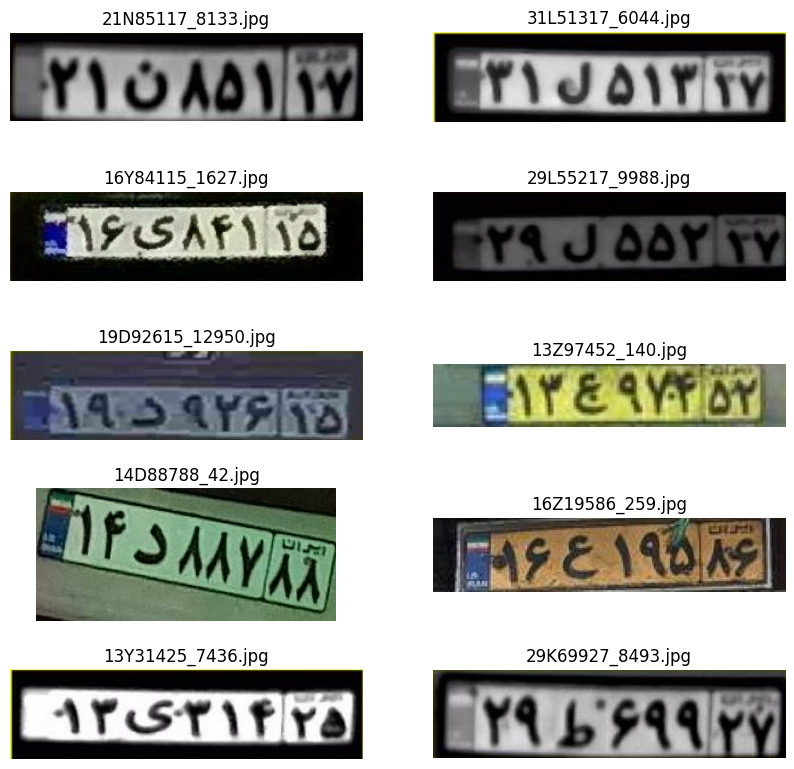

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(10, 10))

for i in range(10):
    img_path = os.path.join(dataset_path, os.listdir(dataset_path)[i])
    binary_image = tf.io.read_file(img_path)
    image = tf.io.decode_jpeg(binary_image)
    plt.subplot(5, 2, i+1)
    plt.imshow(image)
    plt.title(f"{os.path.basename(img_path)}")
    plt.axis('off')

plt.show()
plt.tight_layout()


In [16]:
images_path_list = sorted(os.listdir(dataset_path))
images_path_list = [os.path.join(dataset_path, image_path) for image_path in images_path_list]

labels = [image_path.split('/')[-1].split('.')[0].split("_")[0] for image_path in images_path_list]

print(images_path_list[:10])
print(labels[:10])

['/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B39235_15685.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B49837_6206.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B54337_3939.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B65366_8746.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B68435_7152.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B73117_8093.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11B83164_15251.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11C13215_13508.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11C17715_16187.jpg', '/root/.keras/datasets/iclp-part1_extracted/iclp-part1/11C61315_1645.jpg']
['11B39235', '11B49837', '11B54337', '11B65366', '11B68435', '11B73117', '11B83164', '11C13215', '11C17715', '11C61315']


In [19]:
characters = sorted(set([char for label in labels for char in label]))
print(f"Characters: {characters}")
print(f"Number of characters: {len(characters)}")

Characters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'H', 'J', 'K', 'L', 'M', 'N', 'S', 'T', 'V', 'X', 'Y', 'Z']
Number of characters: 26
